In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [3]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent/"02_src"))

In [4]:
from db import get_engine
engine = get_engine()

Loading environment variables from: C:\Users\nabap\Desktop\olive_e-commerce\config\db_config.env
File Exists: True


In [15]:
df = pd.read_sql('select * from gold.fact_order_summary', engine)

In [16]:
df.head()

,order_id,customer_id,order_status,purchase_time,approve_time,delivered_customer_date,estimate_delivery_date,delivered_carrier_date,delay_days,delivery_time,seller_delay,logistic_delay,total_items,total_price,total_freight,total_payment,payment_count,review_score,customer_city,customer_state
0,8e6bfb81e283fa7e4f11123a3fb894f1,5986b333ca0d44534a156a52a8e33a83,delivered,2018-02-10 10:59:03,2018-02-10 15:48:21,2018-02-28 16:33:35,2018-03-09,2018-02-15 19:36:14,-9 days +16:33:35,18 days 05:34:32,5 days 03:47:53,12 days 20:57:21,1,1199.0,134.25,1333.25,1.0,5.0,curitibanos,sc
1,b18dcdf73be66366873cd26c5724d1dc,eecafc3ff695f031bfe354a9fff9d437,delivered,2018-04-06 22:18:54,2018-04-09 20:10:35,2018-04-12 17:17:53,2018-05-03,2018-04-11 16:48:35,-21 days +17:17:53,5 days 18:58:59,1 days 20:38:00,1 days 00:29:18,4,418.7,44.00,462.70,1.0,1.0,sao paulo,sp
2,e48aa0d2dcec3a2e87348811bcfdf22b,840be0730010e9580efd289bc9f37706,delivered,2017-06-30 15:38:46,2017-06-30 15:50:17,2017-07-15 12:57:24,2017-08-03,2017-07-03 16:22:53,-19 days +12:57:24,14 days 21:18:38,3 days 00:32:36,11 days 20:34:31,1,46.9,11.85,58.75,1.0,5.0,sao paulo,sp
3,c31a859e34e3adac22f376954e19b39d,98f485515e575607a8003b17e91990bd,delivered,2018-08-07 23:12:29,2018-08-07 23:25:10,2018-08-13 18:08:28,2018-10-10,2018-08-08 14:18:00,-58 days +18:08:28,5 days 18:55:59,0 days 14:52:50,5 days 03:50:28,1,139.9,59.06,198.96,1.0,5.0,resende,rj
4,0ce9a24111d850192a933fcaab6fbad3,5bb8de60ca2ca8b01a5ce471802fe10b,delivered,2017-11-24 01:40:48,2017-11-24 01:49:34,2017-12-13 00:28:44,2017-12-19,2017-12-06 15:19:09,-6 days +00:28:44,18 days 22:47:56,12 days 13:29:35,6 days 09:09:35,1,159.9,28.50,188.40,1.0,1.0,rio de janeiro,rj


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 97007 entries, 0 to 97006
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype          
---  ------                   --------------  -----          
 0   order_id                 97007 non-null  str            
 1   customer_id              97007 non-null  str            
 2   order_status             97007 non-null  str            
 3   purchase_time            97007 non-null  datetime64[us] 
 4   approve_time             96993 non-null  datetime64[us] 
 5   delivered_customer_date  96999 non-null  datetime64[us] 
 6   estimate_delivery_date   97007 non-null  datetime64[us] 
 7   delivered_carrier_date   97005 non-null  datetime64[us] 
 8   delay_days               96999 non-null  timedelta64[us]
 9   delivery_time            96999 non-null  timedelta64[us]
 10  seller_delay             96991 non-null  timedelta64[us]
 11  logistic_delay           96998 non-null  timedelta64[us]
 12  total_items              9700

In [18]:
df.shape

(97007, 20)

In [20]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
purchase_time,97007,2018-01-01 15:37:47.535074,2016-09-15 12:16:38,2017-09-13 19:55:58.500000,2018-01-20 13:20:35,2018-05-05 10:59:43,2018-08-29 15:00:37,NaN
approve_time,96993,2018-01-02 03:01:25.057674,2016-09-15 12:16:38,2017-09-14 07:25:28,2018-01-20 19:20:37,2018-05-05 17:10:23,2018-08-29 15:10:26,NaN
delivered_customer_date,96999,2018-01-14 04:58:15.062763,2016-10-11 13:46:32,2017-09-25 20:11:17.500000,2018-02-02 16:09:06,2018-05-15 20:03:15.500000,2018-10-17 13:22:46,NaN
estimate_delivery_date,97007,2018-01-25 09:32:15.732473,2016-10-04 00:00:00,2017-10-05 00:00:00,2018-02-16 00:00:00,2018-05-28 00:00:00,2018-10-25 00:00:00,NaN
delivered_carrier_date,97005,2018-01-04 21:13:02.244719,2016-10-08 10:34:01,2017-09-15 21:49:52,2018-01-24 01:14:44,2018-05-08 13:41:00,2018-09-11 19:48:28,NaN
delay_days,96999,-12 days +19:37:46.410922,-147 days +23:36:47,-17 days +18:07:45.500000,-12 days +01:11:47,-7 days +14:35:19,188 days 23:24:07,10 days 04:25:42.859592
delivery_time,96999,12 days 13:32:14.314683,0 days 12:48:07,6 days 18:30:27.500000,10 days 05:23:58,15 days 17:33:17.500000,209 days 15:05:12,9 days 13:01:02.992898
seller_delay,96991,2 days 19:13:25.952160,-172 days +18:44:38,0 days 21:00:02.500000,1 days 19:38:12,3 days 13:52:35,125 days 18:18:06,3 days 12:49:36.791024
logistic_delay,96998,9 days 08:01:04.349574,-17 days +21:41:31,4 days 02:27:38.250000,7 days 02:25:25,12 days 00:49:32,205 days 04:35:00,8 days 18:11:17.892278
total_items,97007.0,1.142598,1.0,1.0,1.0,1.0,21.0,0.540014


Dataset contains review_score null, which implies that some of the customer didn't leave review.

We can't remove it from main dataset, because it will impact the delay/logistic analysis.

That's why we handle it separetly for review analysis.

In [142]:
df_review = df[df['review_score'].notna()]

In [28]:
df = df.dropna(subset=[
    'approve_time',
    'delivered_customer_date',
    'delivered_carrier_date',
    'delay_days',
    'delivery_time',
    'seller_delay',
    'logistic_delay',
    'total_payment',
    'payment_count'
])

In [42]:
df['delay_days_num'] = df['delay_days'].dt.total_seconds() / (24 * 3600)
df['seller_delay_num'] = df['seller_delay'].dt.total_seconds() / (24 * 3600)
df['logistic_delay_num'] = df['logistic_delay'].dt.total_seconds() / (24 * 3600)
df['delivery_time_num'] = df['delivery_time'].dt.total_seconds() / (24 * 3600)

In [43]:
df.head()

,order_id,customer_id,order_status,purchase_time,approve_time,delivered_customer_date,estimate_delivery_date,delivered_carrier_date,delay_days,delivery_time,...,total_freight,total_payment,payment_count,review_score,customer_city,customer_state,delay_days_num,seller_delay_num,logistic_delay_num,delivery_time_num
0,8e6bfb81e283fa7e4f11123a3fb894f1,5986b333ca0d44534a156a52a8e33a83,delivered,2018-02-10 10:59:03,2018-02-10 15:48:21,2018-02-28 16:33:35,2018-03-09,2018-02-15 19:36:14,-9 days +16:33:35,18 days 05:34:32,...,134.25,1333.25,1.0,5.0,curitibanos,sc,-8.310012,5.158252,12.873160,18.232315
1,b18dcdf73be66366873cd26c5724d1dc,eecafc3ff695f031bfe354a9fff9d437,delivered,2018-04-06 22:18:54,2018-04-09 20:10:35,2018-04-12 17:17:53,2018-05-03,2018-04-11 16:48:35,-21 days +17:17:53,5 days 18:58:59,...,44.00,462.70,1.0,1.0,sao paulo,sp,-20.279248,1.859722,1.020347,5.790961
2,e48aa0d2dcec3a2e87348811bcfdf22b,840be0730010e9580efd289bc9f37706,delivered,2017-06-30 15:38:46,2017-06-30 15:50:17,2017-07-15 12:57:24,2017-08-03,2017-07-03 16:22:53,-19 days +12:57:24,14 days 21:18:38,...,11.85,58.75,1.0,5.0,sao paulo,sp,-18.460139,3.022639,11.857303,14.887940
3,c31a859e34e3adac22f376954e19b39d,98f485515e575607a8003b17e91990bd,delivered,2018-08-07 23:12:29,2018-08-07 23:25:10,2018-08-13 18:08:28,2018-10-10,2018-08-08 14:18:00,-58 days +18:08:28,5 days 18:55:59,...,59.06,198.96,1.0,5.0,resende,rj,-57.244120,0.620023,5.160046,5.788877
4,0ce9a24111d850192a933fcaab6fbad3,5bb8de60ca2ca8b01a5ce471802fe10b,delivered,2017-11-24 01:40:48,2017-11-24 01:49:34,2017-12-13 00:28:44,2017-12-19,2017-12-06 15:19:09,-6 days +00:28:44,18 days 22:47:56,...,28.50,188.40,1.0,1.0,rio de janeiro,rj,-5.980046,12.562211,6.381655,18.949954


In [44]:
df.isnull().sum()

order_id                     0
customer_id                  0
order_status                 0
purchase_time                0
approve_time                 0
delivered_customer_date      0
estimate_delivery_date       0
delivered_carrier_date       0
delay_days                   0
delivery_time                0
seller_delay                 0
logistic_delay               0
total_items                  0
total_price                  0
total_freight                0
total_payment                0
payment_count                0
review_score               646
customer_city                0
customer_state               0
delay_days_num               0
seller_delay_num             0
logistic_delay_num           0
delivery_time_num            0
dtype: int64

#### Create new required columns

In [47]:
df['is_late'] = (df['delay_days_num'] > 0).astype(int)

In [51]:
df.head()

,order_id,customer_id,order_status,purchase_time,approve_time,delivered_customer_date,estimate_delivery_date,delivered_carrier_date,delay_days,delivery_time,...,total_payment,payment_count,review_score,customer_city,customer_state,delay_days_num,seller_delay_num,logistic_delay_num,delivery_time_num,is_late
0,8e6bfb81e283fa7e4f11123a3fb894f1,5986b333ca0d44534a156a52a8e33a83,delivered,2018-02-10 10:59:03,2018-02-10 15:48:21,2018-02-28 16:33:35,2018-03-09,2018-02-15 19:36:14,-9 days +16:33:35,18 days 05:34:32,...,1333.25,1.0,5.0,curitibanos,sc,-8.310012,5.158252,12.873160,18.232315,0
1,b18dcdf73be66366873cd26c5724d1dc,eecafc3ff695f031bfe354a9fff9d437,delivered,2018-04-06 22:18:54,2018-04-09 20:10:35,2018-04-12 17:17:53,2018-05-03,2018-04-11 16:48:35,-21 days +17:17:53,5 days 18:58:59,...,462.70,1.0,1.0,sao paulo,sp,-20.279248,1.859722,1.020347,5.790961,0
2,e48aa0d2dcec3a2e87348811bcfdf22b,840be0730010e9580efd289bc9f37706,delivered,2017-06-30 15:38:46,2017-06-30 15:50:17,2017-07-15 12:57:24,2017-08-03,2017-07-03 16:22:53,-19 days +12:57:24,14 days 21:18:38,...,58.75,1.0,5.0,sao paulo,sp,-18.460139,3.022639,11.857303,14.887940,0
3,c31a859e34e3adac22f376954e19b39d,98f485515e575607a8003b17e91990bd,delivered,2018-08-07 23:12:29,2018-08-07 23:25:10,2018-08-13 18:08:28,2018-10-10,2018-08-08 14:18:00,-58 days +18:08:28,5 days 18:55:59,...,198.96,1.0,5.0,resende,rj,-57.244120,0.620023,5.160046,5.788877,0
4,0ce9a24111d850192a933fcaab6fbad3,5bb8de60ca2ca8b01a5ce471802fe10b,delivered,2017-11-24 01:40:48,2017-11-24 01:49:34,2017-12-13 00:28:44,2017-12-19,2017-12-06 15:19:09,-6 days +00:28:44,18 days 22:47:56,...,188.40,1.0,1.0,rio de janeiro,rj,-5.980046,12.562211,6.381655,18.949954,0


#### Distribution of numeric_cols

<function matplotlib.pyplot.show(close=None, block=None)>

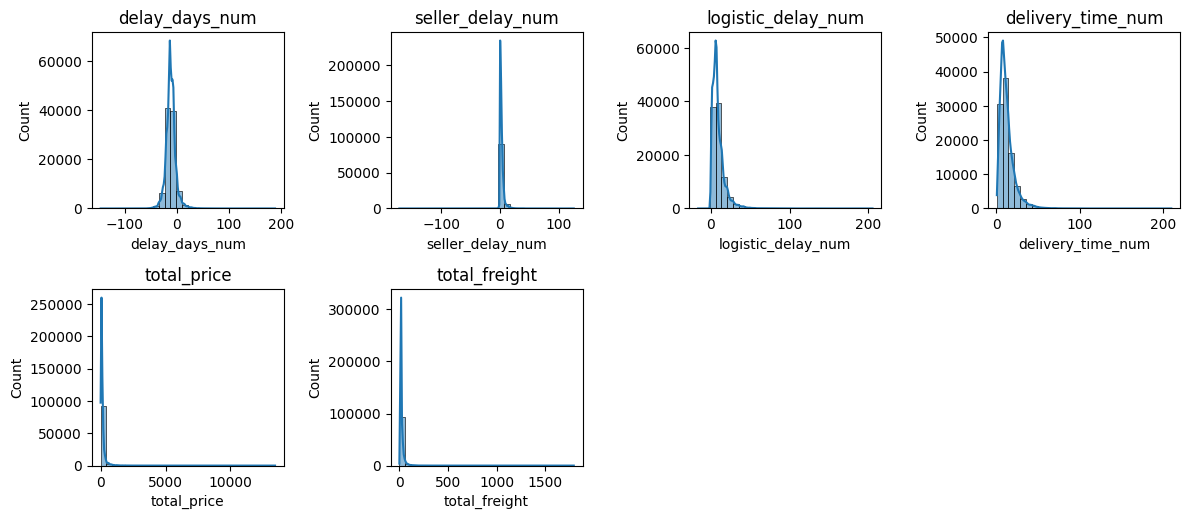

In [45]:
numerical_cols = ['delay_days_num',
                  'seller_delay_num',
                  'logistic_delay_num',
                  'delivery_time_num',
                  'total_price',
                  'total_freight']
plt.figure(figsize=(12,10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show

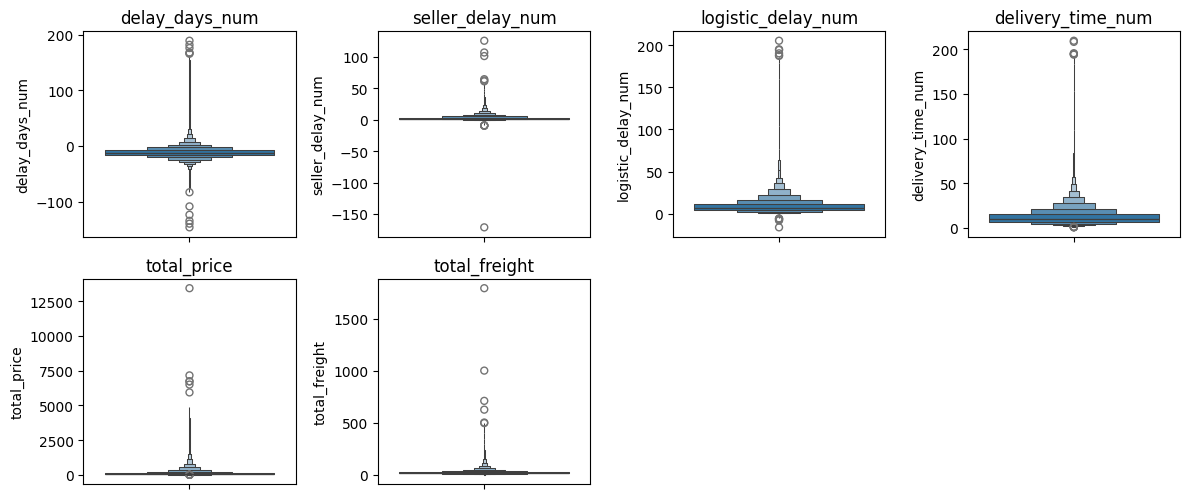

In [53]:
plt.figure(figsize=(12,10))

for i, col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.boxenplot(df[col],)
    plt.title(col)
plt.tight_layout()
plt.show()

#### Distribution of categorical_cols

In [63]:
df['customer_state'] = df['customer_state'].str.upper()

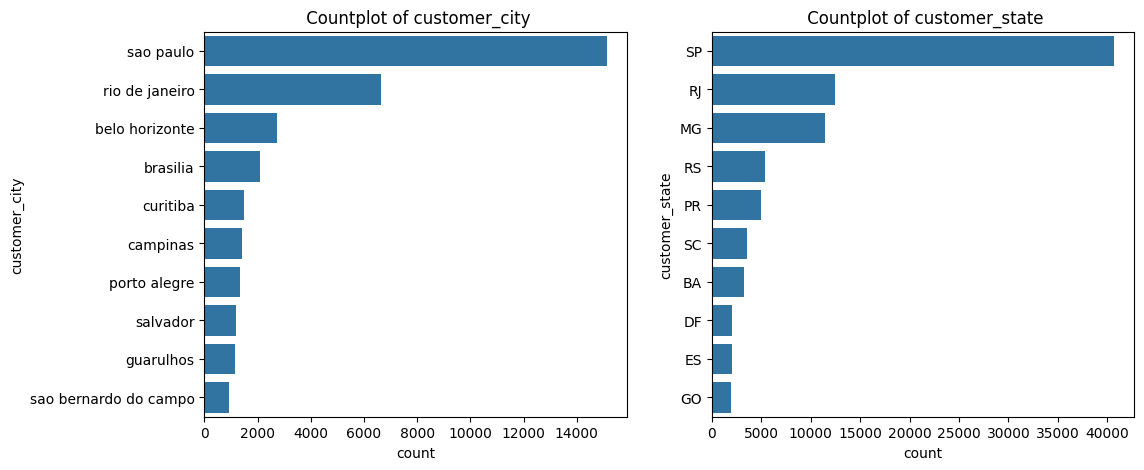

In [64]:
categorical_cols = ['customer_city','customer_state']

plt.figure(figsize=(12,5))

for i, col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)
    total_vals = df[col].value_counts().index[:10]
    sns.countplot(y=df[df[col].isin(total_vals)][col], order=total_vals)
    plt.title(f' Countplot of {col}')
plt.tight_layout
plt.show()

#### Correlation between the numerical_cols

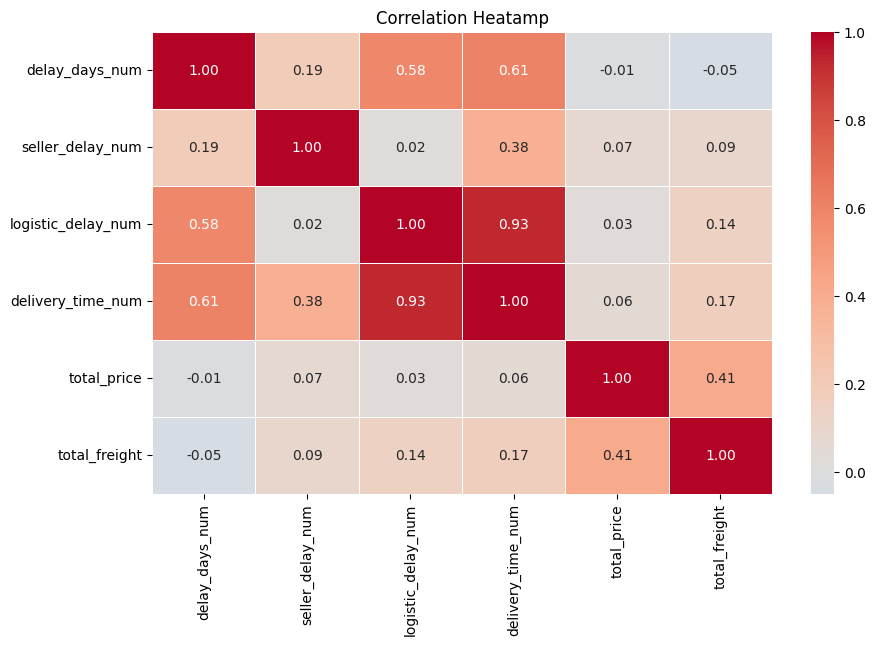

In [71]:
plt.figure(figsize=(10,6))

correlation_matric = df[numerical_cols].corr()
sns.heatmap(correlation_matric, annot=True, fmt='.2f',center=0, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatamp')
plt.show()

## Business question analysis

### Q. What % of orders are delivered late ?

In [87]:
df['is_late'] = (df['is_late'] > 0)

late_pct = round(((df['is_late']/df.shape[0]) * 100).sum(), 2)
late_number = df['is_late'].count()

print(f'Total number of late delivered orders: {late_number}')
print(f'Total percentage of late delivered orders: {late_pct}%')

Total number of late delivered orders: 96983
Total percentage of late delivered orders: 8.11%


In [85]:
df['delay_bucket'] = pd.cut(df['delay_days_num'],
                            bins=[-100,0,2,100],
                            labels=['on_time','slight_delay','high_delay']
                        )
bucket_pct = round(df['delay_bucket'].value_counts(normalize=True) * 100, 2)
bucket_pct

delay_bucket
on_time         91.93
high_delay       5.87
slight_delay     2.20
Name: proportion, dtype: float64

### Q. Which region/state causes the delays?

In [97]:
city_delay = df.groupby('customer_city').agg(
                            total_orders = ('order_id','count'),
                            late_rate = ('is_late','mean'),
                            avg_delay = ('delay_days_num','mean')
                    ).reset_index()

city_delay = city_delay[city_delay['total_orders'] > 100]
city_delay.sort_values(by='late_rate', ascending=False, inplace=True)
top_city = city_delay.head(10)
top_city

,customer_city,total_orders,late_rate,avg_delay
2132,maceio,237,0.299578,-5.771497
3438,sao goncalo,387,0.250646,-5.754646
604,cabo frio,113,0.238938,-5.742311
3532,sao luis,336,0.223214,-8.008530
3809,teresina,272,0.220588,-7.853593
3460,sao joao de meriti,124,0.217742,-6.185875
2479,nova friburgo,146,0.212329,-5.266889
1542,hortolandia,142,0.211268,-6.201209
3123,rio das ostras,130,0.207692,-6.924989
3071,resende,115,0.191304,-7.959766


In [96]:
state_delay = df.groupby('customer_state').agg(
                            total_orders = ('order_id','count'),
                            late_rate = ('is_late','mean'),
                            avg_delay = ('delay_days_num','mean')
                    ).reset_index()

state_delay = state_delay[state_delay['total_orders'] > 100]
state_delay.sort_values(by='late_rate', ascending=False, inplace=True)
top_state = state_delay.head(10)
top_state

,customer_state,total_orders,late_rate,avg_delay
1,AL,401,0.239401,-8.039266
9,MA,720,0.195833,-8.933795
16,PI,477,0.159329,-10.620075
5,CE,1281,0.153786,-10.114451
24,SE,335,0.152239,-9.328641
4,BA,3273,0.140849,-10.089637
18,RJ,12418,0.134804,-11.044933
26,TO,274,0.127737,-11.439738
13,PA,952,0.122899,-13.373718
7,ES,2004,0.122255,-9.800671


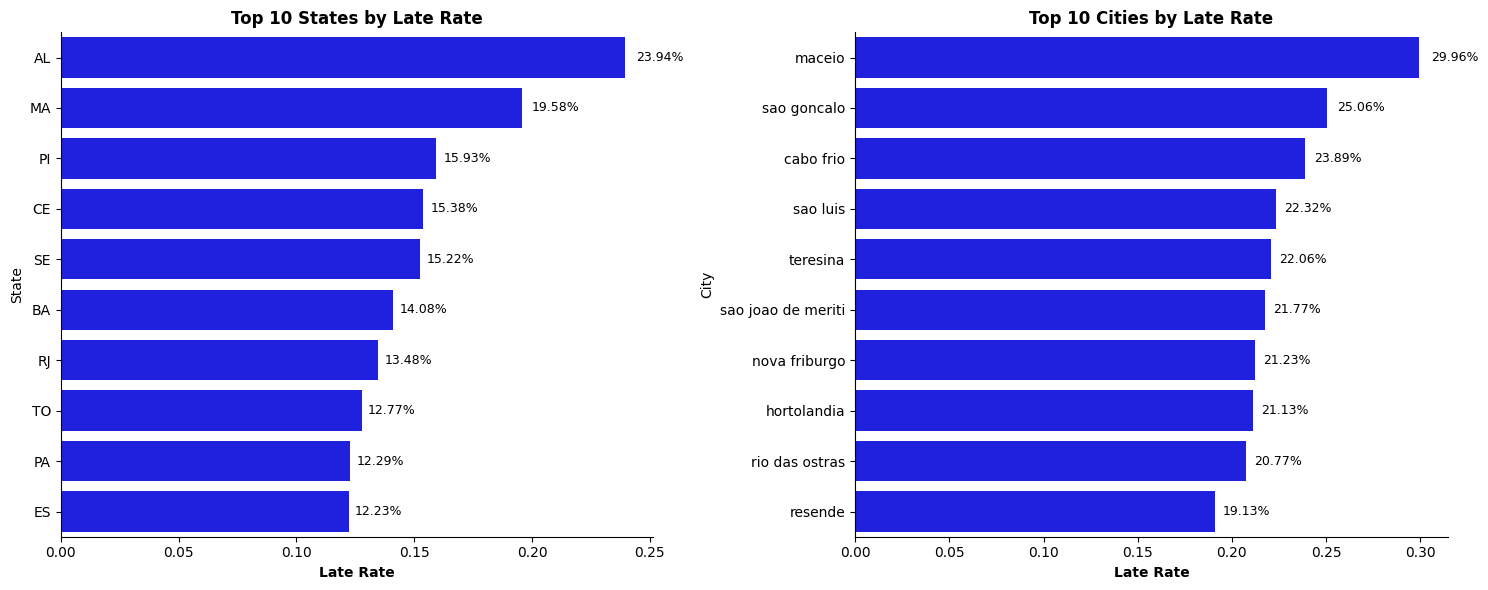

In [112]:
top_state
top_city

fig, axes = plt.subplots(1, 2, figsize=(15,6))
# plot for top vendors 
sns.barplot(data=top_state, x='late_rate', y='customer_state', color='blue', ax=axes[0])
axes[0].set_title('Top 10 States by Late Rate', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Late Rate',fontweight='bold')
axes[0].set_ylabel('State')
axes[0].grid(False)
for i, v in enumerate(top_state['late_rate']):
    axes[0].text(v + (v * 0.02), i, f"{v*100:.2f}%", va='center', fontsize=9, ha='left', color='black')

# plot for top brands
sns.barplot(data=top_city, x='late_rate', y='customer_city', color='blue', ax=axes[1])
axes[1].set_title('Top 10 Cities by Late Rate', fontsize=12, fontweight='bold')         
axes[1].set_xlabel('Late Rate',fontweight='bold')
axes[1].set_ylabel('City')
axes[1].grid(False)
for i, v in enumerate(top_city['late_rate']):
    axes[1].text(v + (v * 0.02), i, f"{v*100:.2f}%", va='center', fontsize=9, ha='left', color='black')

sns.despine()
plt.tight_layout()
plt.show()

Top 10 state and city with highest average logistic delay 

In [ ]:
# top 10 states by logistic delay

top_state_logistic =(df.groupby('customer_state')
                     .agg(logistic_delay_num=('logistic_delay_num', 'mean'))
                     .round(2)
                     .sort_values(by='logistic_delay_num', ascending=False)
                     .head(10)
                     .reset_index() 
)
top_state_logistic

,customer_state,logistic_delay_num
0,RR,25.64
1,AP,23.66
2,AM,23.48
3,AL,21.07
4,PA,20.30
5,SE,17.95
6,MA,17.94
7,CE,17.94
8,AC,17.56
9,PB,16.91


In [124]:
# top 10 cities by logistic delay

top_city_logistic = (df.groupby('customer_city')
                     .agg(logistic_delay_num=('logistic_delay_num', 'mean'))
                     .round(2)
                     .sort_values(by='logistic_delay_num', ascending=False)
                     .head(10)
                     .reset_index()
)
top_city_logistic

,customer_city,logistic_delay_num
0,novo brasil,145.94
1,capinzal do norte,104.34
2,adhemar de barros,92.41
3,arace,81.39
4,marcelino vieira,71.84
5,aramari,71.21
6,humildes,69.93
7,serra dos dourados,69.89
8,santa cruz de goias,65.00
9,rubineia,60.78


### Q. Is delay due to seller processing or logistic/shipping ?

In [127]:
late_df = df[df['is_late'] == True]
seller_delay_avg = late_df['seller_delay_num'].mean()
logistic_delay_avg = late_df['logistic_delay_num'].mean()

print(f'Average Seller Delay for Late Orders: {seller_delay_avg:.2f} days')
print(f'Average Logistic Delay for Late Orders: {logistic_delay_avg:.2f} days')

Average Seller Delay for Late Orders: 5.31 days
Average Logistic Delay for Late Orders: 25.70 days


In [134]:
total_delay = df['seller_delay_num'] + df['logistic_delay_num']

seller_delay_pct = (df['seller_delay_num'] / total_delay).mean() * 100
logistic_delay_pct = (df['logistic_delay_num'] / total_delay).mean() * 100

print(f' Total number of late delivery: {total_delay.count()}')
print(f'Average Percentage of Seller Delay: {seller_delay_pct:.2f}%')
print(f'Average Percentage of Logistic Delay: {logistic_delay_pct:.2f}%')

 Total number of late delivery: 96983
Average Percentage of Seller Delay: 24.94%
Average Percentage of Logistic Delay: 75.06%


In [ ]:
# 

late_df.groupby('customer_state').agg(
    avg_logistic_delay = ('logistic_delay_num', 'mean')).round(2).sort_values(by='avg_logistic_delay', ascending=False).head(10)


,avg_logistic_delay
customer_state,
AP,84.12
RR,73.71
AM,57.87
AC,54.93
PA,42.70
SE,39.48
RN,38.88
RO,38.59
CE,37.99


### Q. Does the high freight and price impact delivery time?

In [135]:
df['freight_bucket'] = pd.qcut(df['total_freight'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

df.groupby('freight_bucket').agg(
    avg_delay_days = ('delay_days_num', 'mean'),
    avg_delivery_time = ('delivery_time_num', 'mean'),
)

,avg_delay_days,avg_delivery_time
freight_bucket,,
Low,-9.519971,7.772014
Medium,-11.138315,12.974825
High,-11.896747,14.051754
Very High,-12.173711,15.464145


In [136]:
df['price_bucket'] = pd.qcut(df['total_price'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
df.groupby('price_bucket').agg(
    avg_delay_days = ('delay_days_num', 'mean'),
    avg_delivery_time = ('delivery_time_num', 'mean'),
)

,avg_delay_days,avg_delivery_time
price_bucket,,
Low,-10.943218,11.463052
Medium,-10.958023,12.292628
High,-11.329384,12.824688
Very High,-11.496367,13.686137


## Review Score Analysis abd Delay Relationship



### Q. How does the delay impact on reviews?

In [143]:
df_review.head()

,order_id,customer_id,order_status,purchase_time,approve_time,delivered_customer_date,estimate_delivery_date,delivered_carrier_date,delay_days,delivery_time,...,customer_city,customer_state,delay_days_num,seller_delay_num,logistic_delay_num,delivery_time_num,is_late,delay_bucket,freight_bucket,price_bucket
0,8e6bfb81e283fa7e4f11123a3fb894f1,5986b333ca0d44534a156a52a8e33a83,delivered,2018-02-10 10:59:03,2018-02-10 15:48:21,2018-02-28 16:33:35,2018-03-09,2018-02-15 19:36:14,-9 days +16:33:35,18 days 05:34:32,...,curitibanos,SC,-8.310012,5.158252,12.873160,18.232315,False,on_time,Very High,Very High
1,b18dcdf73be66366873cd26c5724d1dc,eecafc3ff695f031bfe354a9fff9d437,delivered,2018-04-06 22:18:54,2018-04-09 20:10:35,2018-04-12 17:17:53,2018-05-03,2018-04-11 16:48:35,-21 days +17:17:53,5 days 18:58:59,...,sao paulo,SP,-20.279248,1.859722,1.020347,5.790961,False,on_time,Very High,Very High
2,e48aa0d2dcec3a2e87348811bcfdf22b,840be0730010e9580efd289bc9f37706,delivered,2017-06-30 15:38:46,2017-06-30 15:50:17,2017-07-15 12:57:24,2017-08-03,2017-07-03 16:22:53,-19 days +12:57:24,14 days 21:18:38,...,sao paulo,SP,-18.460139,3.022639,11.857303,14.887940,False,on_time,Low,Medium
3,c31a859e34e3adac22f376954e19b39d,98f485515e575607a8003b17e91990bd,delivered,2018-08-07 23:12:29,2018-08-07 23:25:10,2018-08-13 18:08:28,2018-10-10,2018-08-08 14:18:00,-58 days +18:08:28,5 days 18:55:59,...,resende,RJ,-57.244120,0.620023,5.160046,5.788877,False,on_time,Very High,High
4,0ce9a24111d850192a933fcaab6fbad3,5bb8de60ca2ca8b01a5ce471802fe10b,delivered,2017-11-24 01:40:48,2017-11-24 01:49:34,2017-12-13 00:28:44,2017-12-19,2017-12-06 15:19:09,-6 days +00:28:44,18 days 22:47:56,...,rio de janeiro,RJ,-5.980046,12.562211,6.381655,18.949954,False,on_time,Very High,Very High


In [146]:
# use the subset of data with review score not null

df_review['delay_bucket'] = pd.cut(df_review['delay_days_num'],
                            bins=[-100,0,2,100],
                            labels=['on_time','slight_delay','high_delay']
                        )

df_review.groupby('delay_bucket').agg(
    avg_review_score = ('review_score', 'mean'),
    count_reviews = ('review_score', 'count')
)

,avg_review_score,count_reviews
delay_bucket,,
on_time,4.293691,88634
slight_delay,3.915326,2114
high_delay,2.049044,5546


In [149]:
on_time_reviews = df_review[df_review['delay_bucket'] == 'on_time']['review_score'].mean()
late_reviews = df_review[df_review['delay_bucket'] != 'on_time']['review_score'].mean()

impact = on_time_reviews - late_reviews
print(f'average review score drop due to delay: {impact:.2f} points')

average review score drop due to delay: 1.73 points


In [150]:
df_review.groupby('freight_bucket').agg(
    avg_review_score = ('review_score', 'mean')
)

,avg_review_score
freight_bucket,
Low,4.315615
Medium,4.190189
High,4.174820
Very High,3.941321


In [151]:
df_review.groupby('price_bucket').agg(
    avg_review_score = ('review_score', 'mean')
)

,avg_review_score
price_bucket,
Low,4.220216
Medium,4.178789
High,4.156657
Very High,4.065667


## Test Review VS Delay

H0: Delay has no impact on review

H1: Delay impact review

In [152]:
from scipy.stats import ttest_ind

on_time_scores = df_review[df_review['delay_bucket'] == 'on_time']['review_score']
late_scores = df_review[df_review['delay_bucket'] != 'on_time']['review_score'] 

t_stat, p_value = ttest_ind(on_time_scores, late_scores, equal_var=False)
print(f'T-statistic: {t_stat:.2f}, P-value: {p_value:.4f}')

T-statistic: 89.49, P-value: 0.0000


## Seller VS Logistic delay contribution

H0: Seller delay is equal to Logistic delay

H1: Seller dealy is not equal to Logistic delay

In [155]:
from scipy.stats import ttest_ind

late_df = df[df['is_late'] == True]

# use paired t-test because same order 2 measurement before and after delay
# seller_delay and logistic_delay are dependent beacause they are from the same order

t_stat, p_value = ttest_ind(late_df['seller_delay_num'], late_df['logistic_delay_num'])
print(f'T-statistic: {t_stat:.2f}, P-value: {p_value:.4f}')

T-statistic: -94.75, P-value: 0.0000


### Test Freight VS Delivery speed

H0: Freight has no relation with delivery speed

H1: Higher freight equal to faster delivery

In [156]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(df['total_freight'], df['delivery_time_num'])
print(f'Pearson correlation: {corr:.2f}, P-value: {p_value:.4f}')

Pearson correlation: 0.17, P-value: 0.0000


## Quantify business impact analysis



In [157]:
total_revenue = df['total_price'].sum()
late_revenue = df[df['is_late'] == True]['total_price'].sum()

late_revenue_pct = (late_revenue / total_revenue) * 100
print(f'Total Revenue: ${total_revenue:,.2f}')
print(f'Revenue from Late Orders: ${late_revenue:,.2f}')
print(f'Percentage of Revenue from Late Orders: {late_revenue_pct:.2f}%')

Total Revenue: $13,276,603.01
Revenue from Late Orders: $1,163,385.24
Percentage of Revenue from Late Orders: 8.76%
